# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models. 

3. Why is the Gini a good loss function for categorical target variables? 

4. Why do trees tend to overfit, and how can this tendency be constrained? 

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates. 

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

## 1. Trees are made from splitting the features in the dataset into subgroups which is based on features that would do the best at reducing a loss function. It splits recursively until it hits the stopping condition. 
## 2. They do not assume a linear equation between inputs and outputs, but use piecewise constant functions that are adaptive to change in the data patterns
## 3. it is computationally efficient and it encourages splits that bring about pure subsets by penalizing mixed classes. It splits the tree data in a way that keeps similar features together.
## 4. Because it splits the data into the smallest subsets that takes away teh effects of noise, which is why they tend to be overfit. We can mitigate this by limiting how far we split the tree and removing unnecessary branches (pruning)
## 5. This would be false, trees perform well in numerical data as well, they can split numbers at any value to be able to find patterns
## 6. Binary splits are computationally faster, and prevents risking overfitting faster. 
## 7.  You can tell by tell if its overfit by seeing if it has had many splits and has lots of small branches, and by how it performs on new data if it performs well on training. You can tell that its underfit by seeing if it has very few splits, and does a bad job in both training and testing data.
   

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see. 

In [ ]:
#1  Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = "./data/cars_hw.csv"
df = pd.read_csv(data)
df.head()

print("The # of observations is:", df.shape[0])
print("The # of features/covariates/variables is:", df.shape[1])

print("The available variables are:", df.columns.tolist())
df.head()



The # of observations is: 976
The # of features/covariates/variables is: 12
The available variables are: ['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'Price']


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
#2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, 
# create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`.
#  Our target variable will be `Price`. Make a train-test split of your data.
from sklearn.model_selection import train_test_split

categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target_var = 'Price'

df_encoded = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

X = df_encoded[numeric_vars + [col for col in df_encoded.columns if col not in numeric_vars + [target_var]]]
y = df_encoded[target_var]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


The Optimal min_samples_leaf wouldd be: 8
The highest R^2 is: 0.8213135837522154


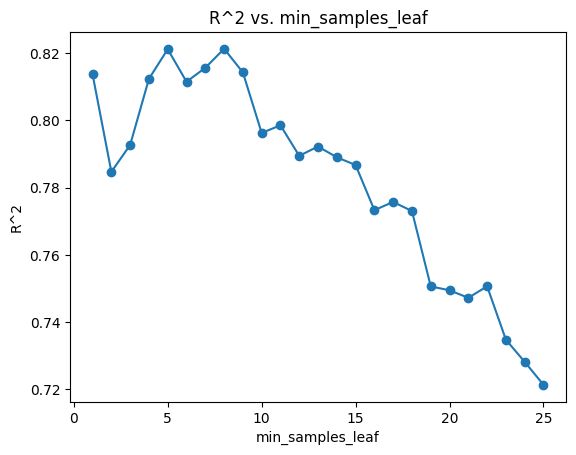

In [10]:
#3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values 
# for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

r2_scores = []
for min_samples_leaf in range(1, 26):
    tree = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

optimal_leaf = np.argmax(r2_scores) + 1
print("The Optimal min_samples_leaf wouldd be:", optimal_leaf)
print("The highest R^2 is:", r2_scores[optimal_leaf - 1])

plt.plot(range(1, 26), r2_scores, marker='o')
plt.xlabel("min_samples_leaf")
plt.ylabel("R^2")
plt.title("R^2 vs. min_samples_leaf")
plt.show()

Decision Tree R^2: 0.8213135837522154
Decision Tree RMSE: 143159.08892903704


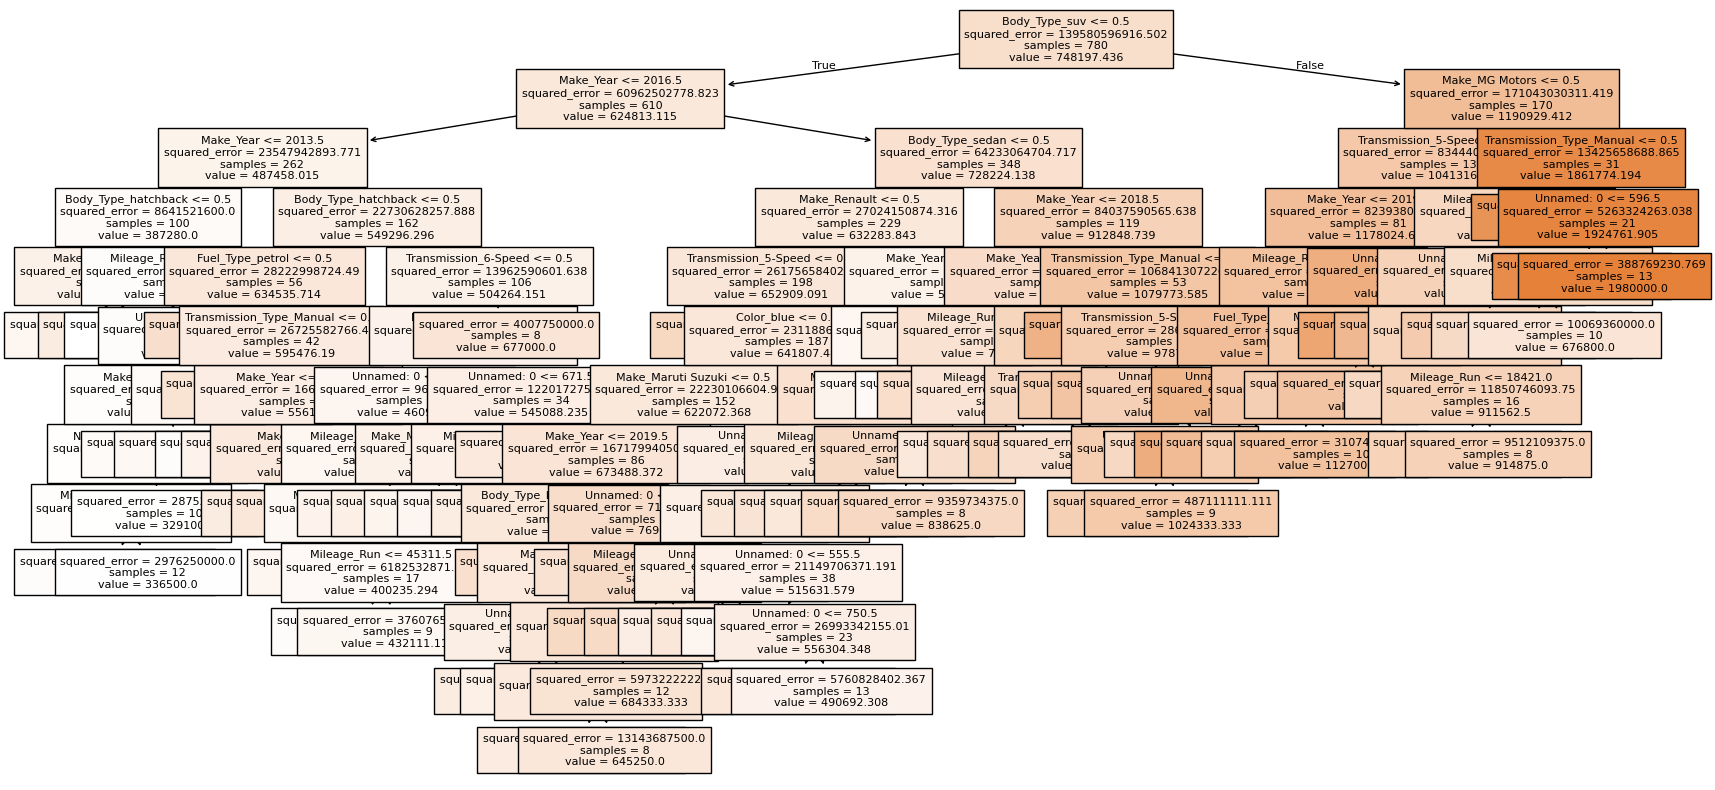

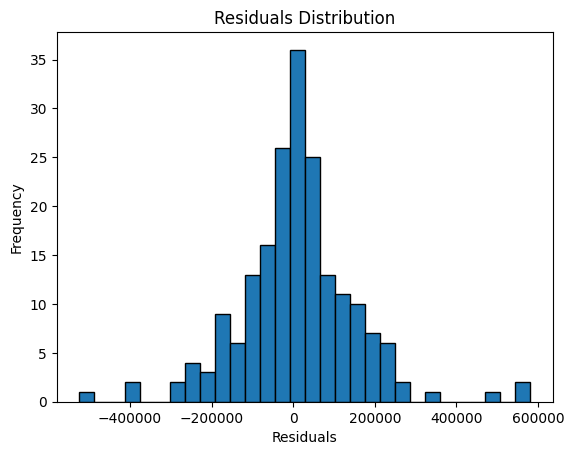

In [11]:
#4 For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. 
# What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

tree = DecisionTreeRegressor(min_samples_leaf=optimal_leaf, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
print("Decision Tree R^2:", r2_tree)
print("Decision Tree RMSE:", rmse_tree)

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=8)
plt.show()

residuals = y_test - y_pred_tree
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.show()



In [ ]:
# 5. Run a linear regression of price on the same variables. Which model -- regression tree or linear 
# regression -- performs better on the test set? Why?

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R^2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)

if r2_tree > r2_lr:
    print("The Decision Tree performs better.")
else:
    print("The Linear Regression performs better.")

Linear Regression R^2: 0.8163910583946421
Linear Regression RMSE: 145117.59426209348
The Decision Tree performs better.


### the density of residuals is symmetric and centered around 0 hooray

### The Decision tree model works better because it produces a smaller root mean squared error than the Linear regression does.

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy? 

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$. 

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [ ]:
#1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? 
# Print out the first few rows of data.
data = "./data/corporate_ratings.csv"
df = pd.read_csv(data)

print("The number of observations: is equal to", df.shape[0])
print("The number of variables is:", df.shape[1])
df.head()


The number of observations: is equal to 2029
The number of variables is: 31


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


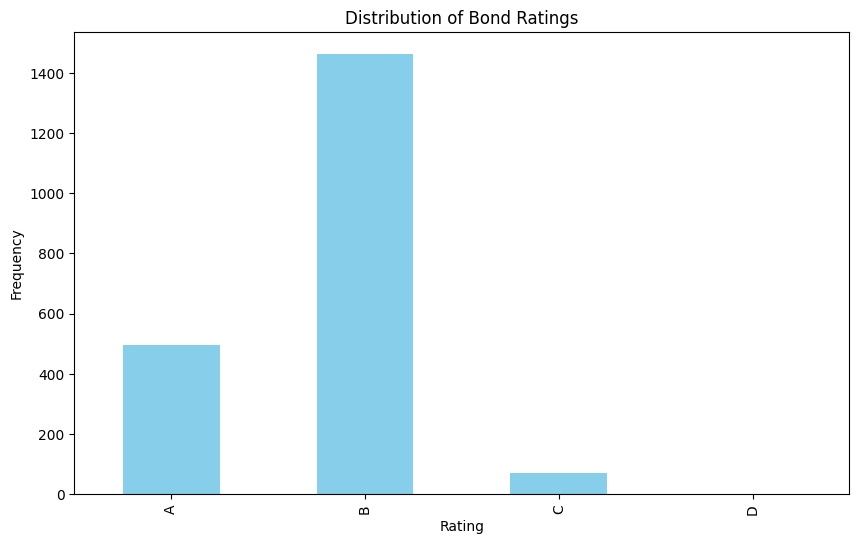

In [ ]:
#2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on 
# make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

df['Rating'] = df['Rating'].replace({'AAA': 'A', 'AA': 'A', 'BBB': 'B', 'BB': 'B', 'CCC': 'C', 'CC': 'C'})

plt.figure(figsize=(10, 6))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bond Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [23]:
#3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. 
# To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. 
# Collect the relevant variables into a data matrix $X$. 

irrelevant_columns = ['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name']
categorical_columns = ['Sector'] 
df_encoded = pd.get_dummies(df.drop(columns=irrelevant_columns), columns=categorical_columns, drop_first=True)

X = df_encoded
y = df['Rating']

In [29]:
#4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating.
# Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the 
# accuracy of your model. How well do you predict the different bond ratings?
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("The accuracy perportion is:", accuracy)


Confusion Matrix:
[[ 47  49   0   0]
 [ 59 227   8   0]
 [  1  11   3   0]
 [  1   0   0   0]]
The accuracy perportion is: 0.6822660098522167


### The model predicted correctly about 68 percent of the time

In [34]:
#5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

if 'Rating Agency Name' in df.columns:
    df_encoded_with_agency = pd.get_dummies(df.drop(columns=['Rating', 'Date', 'Name', 'Symbol']), 
                                            columns=['Sector', 'Rating Agency Name'], drop_first=True)
    X_with_agency = df_encoded_with_agency
    X_train_with_agency, X_test_with_agency, y_train_with_agency, y_test_with_agency = train_test_split(
        X_with_agency, y, test_size=0.2, random_state=42)

    clf_with_agency = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
    clf_with_agency.fit(X_train_with_agency, y_train_with_agency)

    y_pred_with_agency = clf_with_agency.predict(X_test_with_agency)
    accuracy_with_agency = accuracy_score(y_test_with_agency, y_pred_with_agency)

    print("The accuracy with Rating Agency as a feature is equal to:", accuracy_with_agency)
    print("Adding the rating agency as a feature improved the accuracy of the model because agency gives us more predictive power.")

The accuracy with Rating Agency as a feature is equal to: 0.7561576354679803
Adding the rating agency as a feature improved the accuracy of the model because agency gives us more predictive power.


**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree. 

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?